# Project Objectives


1.Predict house prices based on various property features using machine learning techniques.

2.Build and compare regression models using Linear Regression and Random Forest Regressor.

3.Perform Exploratory Data Analysis (EDA), data cleaning, and feature engineering to prepare the dataset.

4.Evaluate model performance using MAE, MSE, RMSE, and R² Score to identify the best-performing model.

5.Deploy the final trained model as an interactive web application using Streamlit.

## Imports


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

import joblib


## Load the data

In [2]:
df_raw = pd.read_csv("data/kc_house_data.csv")
df = df_raw.copy()
print(df.head)


#Column names
print("Column names")
df.columns

#Display basic information
df.info()

#Descriptive analysis
df.describe()

# Check missing values and duplicates
print("Missing values:\n", df.isna().sum())
print("\nDuplicate ids:", df['id'].duplicated().sum())


<bound method NDFrame.head of                id             date     price  bedrooms  bathrooms  \
0      7129300520  20141013T000000  221900.0         3       1.00   
1      6414100192  20141209T000000  538000.0         3       2.25   
2      5631500400  20150225T000000  180000.0         2       1.00   
3      2487200875  20141209T000000  604000.0         4       3.00   
4      1954400510  20150218T000000  510000.0         3       2.00   
...           ...              ...       ...       ...        ...   
21608   263000018  20140521T000000  360000.0         3       2.50   
21609  6600060120  20150223T000000  400000.0         4       2.50   
21610  1523300141  20140623T000000  402101.0         2       0.75   
21611   291310100  20150116T000000  400000.0         3       2.50   
21612  1523300157  20141015T000000  325000.0         2       0.75   

       sqft_living  sqft_lot  floors  waterfront  view  ...  grade  \
0             1180      5650     1.0           0     0  ...      7   
1

## Data Cleaning 

In [3]:
# Always start this section fresh from the raw copy
df = df_raw.copy()

# Convert date to datetime and extract useful parts
df['date'] = pd.to_datetime(df['date'])
df['sale_year'] = df['date'].dt.year
df['sale_month'] = df['date'].dt.month

# Drop id (not predictive) and raw date (already extracted)
df = df.drop(columns=['id', 'date'])

# Sanity check: a house with 33 bedrooms is almost certainly a data entry error
print(df[df['bedrooms'] > 10])

# Fix / drop the obvious outlier row(s)
df = df[df['bedrooms'] <= 10]

# bathrooms = 0 with bedrooms > 0 is suspicious too — inspect before deciding
print(df[(df['bathrooms'] == 0) & (df['bedrooms'] > 0)].shape)

# Capture extreme sqft_lot outliers using the IQR method
Q1 = df['sqft_lot'].quantile(0.25)
Q3 = df['sqft_lot'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR
df = df[df['sqft_lot'] <= upper_bound]

print(df.shape)

          price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
8757   520000.0        11       3.00         3000      4960     2.0   
15870  640000.0        33       1.75         1620      6000     1.0   

       waterfront  view  condition  grade  ...  sqft_basement  yr_built  \
8757            0     0          3      7  ...            600      1918   
15870           0     0          5      7  ...            580      1947   

       yr_renovated  zipcode      lat     long  sqft_living15  sqft_lot15  \
8757           1999    98106  47.5560 -122.363           1420        4960   
15870             0    98103  47.6878 -122.331           1330        4700   

       sale_year  sale_month  
8757        2014           8  
15870       2014           6  

[2 rows x 21 columns]
(3, 21)
(19840, 21)


## Feature Engineering

In [4]:
# --- Create new, more useful features ---
df['house_age'] = df['sale_year'] - df['yr_built']
df['was_renovated'] = (df['yr_renovated'] > 0).astype(int)
df['total_rooms'] = df['bedrooms'] + df['bathrooms']
df['living_lot_ratio'] = df['sqft_living'] / df['sqft_lot']
df['has_basement'] = (df['sqft_basement'] > 0).astype(int)

# --- Drop raw columns now replaced by the features above ---
df = df.drop(columns=[
    'yr_built',        # replaced by house_age
    'yr_renovated',    # replaced by was_renovated
    'sqft_basement',   # replaced by has_basement
])

df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,long,sqft_living15,sqft_lot15,sale_year,sale_month,house_age,was_renovated,total_rooms,living_lot_ratio,has_basement
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,-122.257,1340,5650,2014,10,59,0,4.00,0.208850,0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,-122.319,1690,7639,2014,12,63,1,5.25,0.354874,1
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,-122.233,2720,8062,2015,2,82,0,3.00,0.077000,0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,-122.393,1360,5000,2014,12,49,0,7.00,0.392000,1
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,-122.045,1800,7503,2015,2,28,0,5.00,0.207921,0


## Exploratory Data Analysis (EDA)

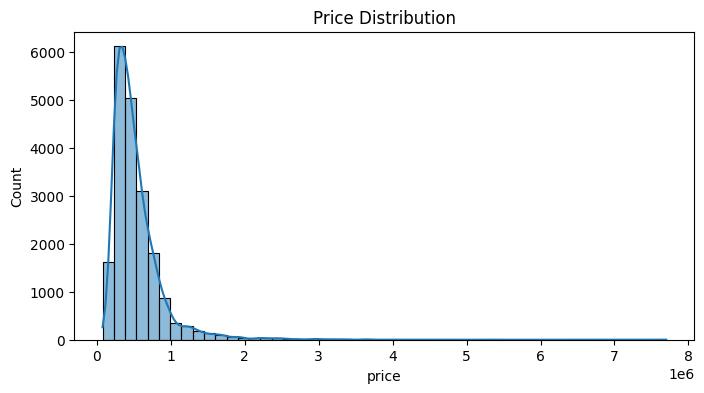

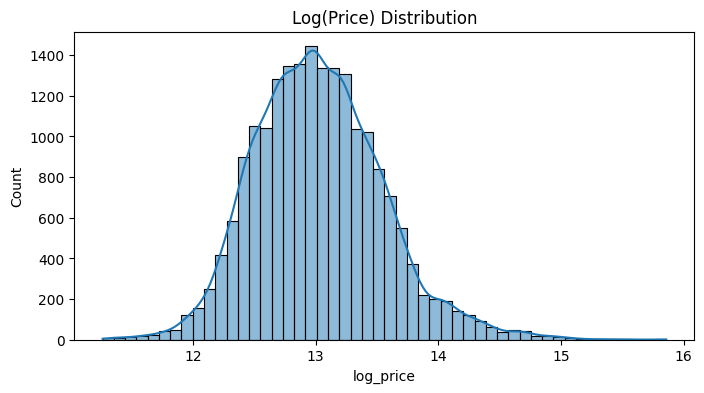

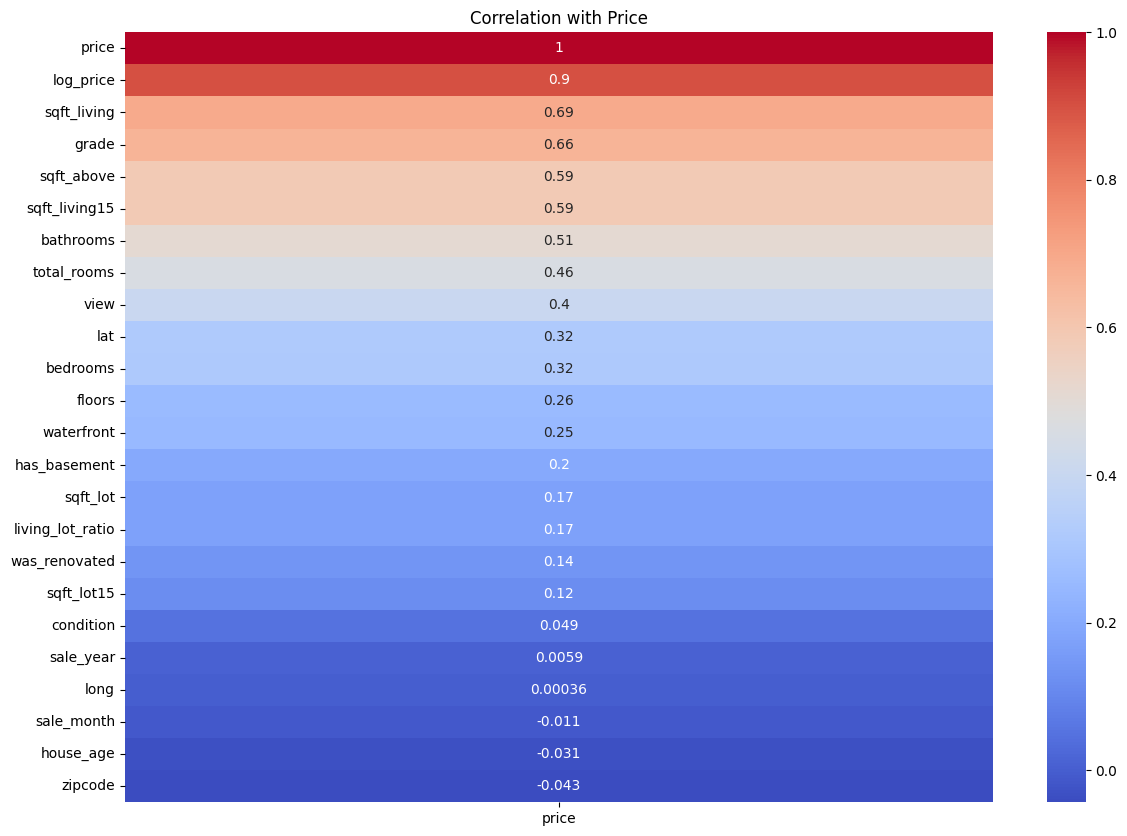

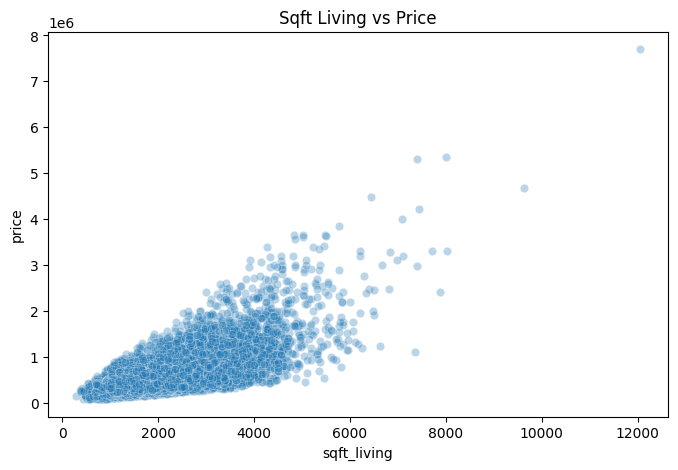

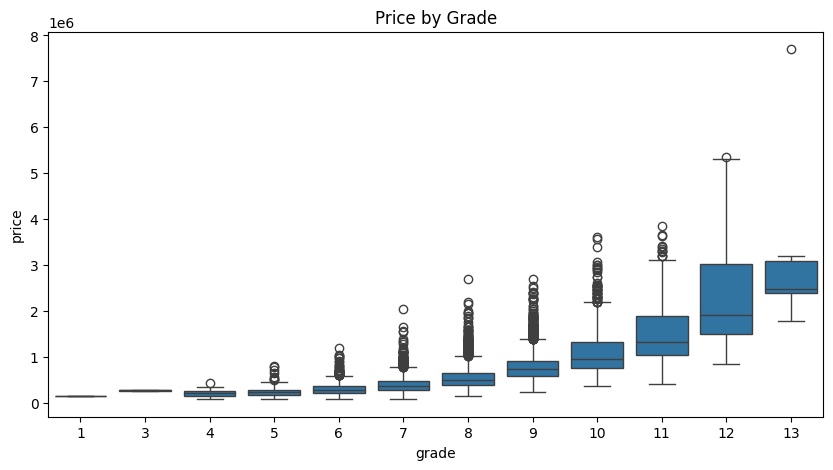

In [5]:
# Target variable distribution
plt.figure(figsize=(8,4))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Price Distribution')
plt.show()

# Price is right-skewed -> log transform often helps linear models
df['log_price'] = np.log1p(df['price'])

plt.figure(figsize=(8,4))
sns.histplot(df['log_price'], bins=50, kde=True)
plt.title('Log(Price) Distribution')
plt.show()

# Correlation heatmap
plt.figure(figsize=(14,10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr[['price']].sort_values(by='price', ascending=False),
            annot=True, cmap='coolwarm')
plt.title('Correlation with Price')
plt.show()

# Price vs sqft_living (strongest predictor)
plt.figure(figsize=(8,5))
sns.scatterplot(x='sqft_living', y='price', data=df, alpha=0.3)
plt.title('Sqft Living vs Price')
plt.show()

# Price by grade (quality rating)
plt.figure(figsize=(10,5))
sns.boxplot(x='grade', y='price', data=df)
plt.title('Price by Grade')
plt.show()

## Prepare features & target

In [6]:
# Use log_price as target for Linear Regression (more normal, better fit)
# but keep raw price for interpretability of final metrics

features = df.drop(columns=['price', 'log_price'])
target = df['log_price']

#one-hot encode zipcode as a categorical variable (it's numeric but not ordinal)
features = pd.get_dummies(features, columns=['zipcode'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(15872, 90) (3968, 90)


## Scale features 

In [7]:
#Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model 1: Linear Regression

In [8]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_preds_log = lr.predict(X_test_scaled)

# convert back to real price scale for interpretable metrics
lr_preds = np.expm1(lr_preds_log)
y_test_actual = np.expm1(y_test)

lr_mae = mean_absolute_error(y_test_actual, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test_actual, lr_preds))
lr_r2 = r2_score(y_test_actual, lr_preds)

print(f"Linear Regression -> MAE: {lr_mae:,.0f} | RMSE: {lr_rmse:,.0f} | R²: {lr_r2:.4f}")

Linear Regression -> MAE: 71,956 | RMSE: 134,143 | R²: 0.8572


##  Model 2: Random Forest Regressor

In [9]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=4,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)  # tree models don't need scaling

rf_preds_log = rf.predict(X_test)
rf_preds = np.expm1(rf_preds_log)

rf_mae = mean_absolute_error(y_test_actual, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test_actual, rf_preds))
rf_r2 = r2_score(y_test_actual, rf_preds)

print(f"Random Forest -> MAE: {rf_mae:,.0f} | RMSE: {rf_rmse:,.0f} | R²: {rf_r2:.4f}")

Random Forest -> MAE: 69,097 | RMSE: 132,364 | R²: 0.8609


## Model Comparison

C:\Users\BOSS\AppData\Local\Temp\ipykernel_23316\3503335337.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results, ax=ax, palette='muted')
C:\Users\BOSS\AppData\Local\Temp\ipykernel_23316\3503335337.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results, ax=ax, palette='muted')
C:\Users\BOSS\AppData\Local\Temp\ipykernel_23316\3503335337.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results, ax=ax, palette='muted')


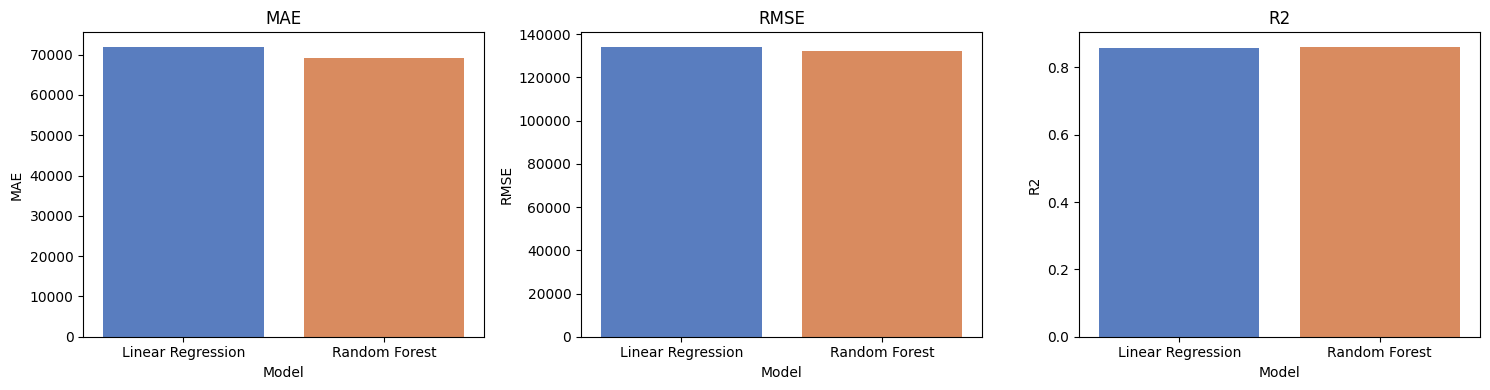

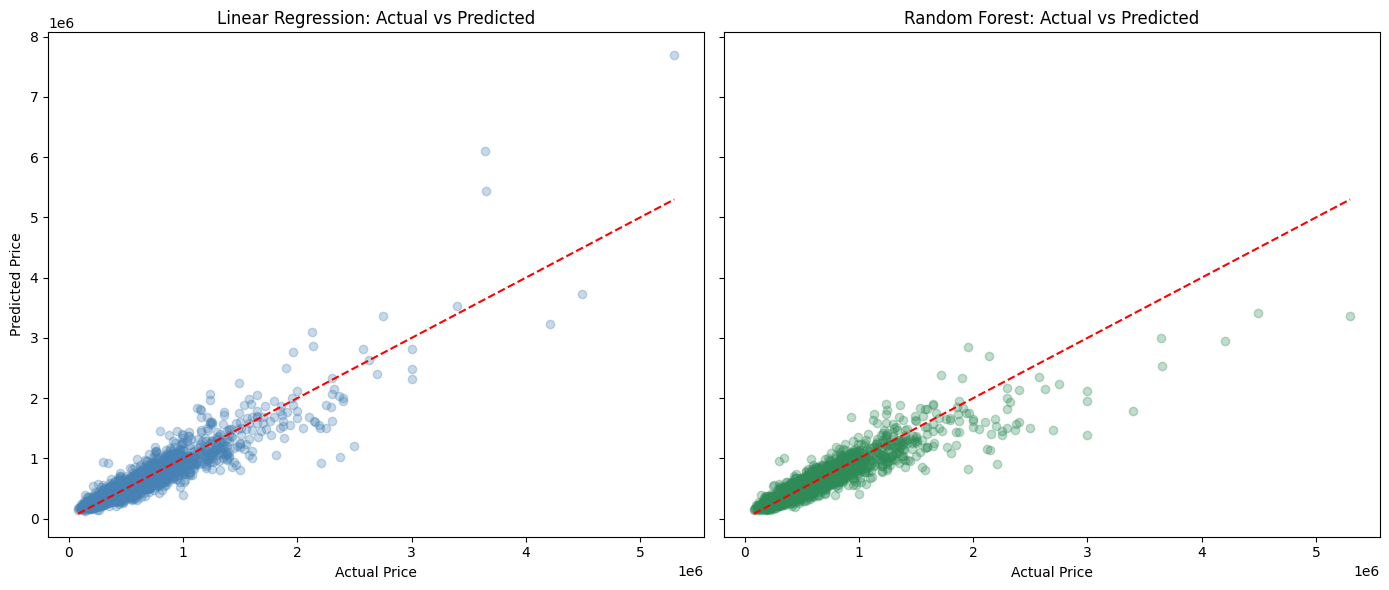

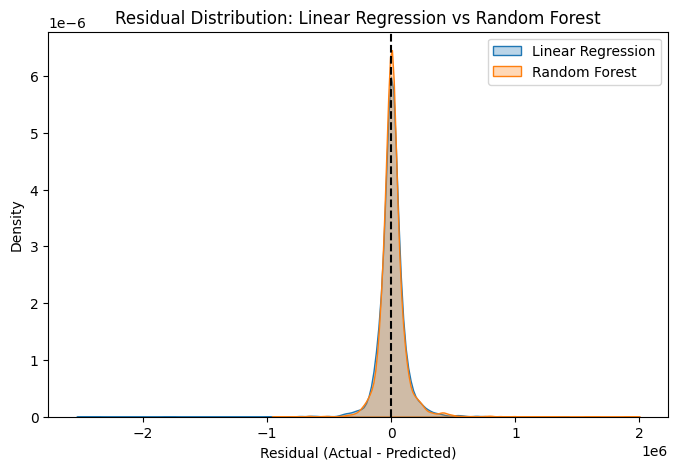

Best model based on RMSE: Random Forest


In [10]:
# --- Collect metrics for both models into one table ---
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2': [lr_r2, rf_r2]
})
results

# --- Bar chart comparing metrics visually ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    sns.barplot(x='Model', y=metric, data=results, ax=ax, palette='muted')
    ax.set_title(metric)

plt.tight_layout()
plt.show()

# --- Actual vs Predicted: both models side by side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

axes[0].scatter(y_test_actual, lr_preds, alpha=0.3, color='steelblue')
axes[0].plot([y_test_actual.min(), y_test_actual.max()],
             [y_test_actual.min(), y_test_actual.max()], 'r--')
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')

axes[1].scatter(y_test_actual, rf_preds, alpha=0.3, color='seagreen')
axes[1].plot([y_test_actual.min(), y_test_actual.max()],
             [y_test_actual.min(), y_test_actual.max()], 'r--')
axes[1].set_title('Random Forest: Actual vs Predicted')
axes[1].set_xlabel('Actual Price')

plt.tight_layout()
plt.show()

# --- Residual comparison (errors) ---
lr_residuals = y_test_actual - lr_preds
rf_residuals = y_test_actual - rf_preds

plt.figure(figsize=(8, 5))
sns.kdeplot(lr_residuals, label='Linear Regression', fill=True, alpha=0.3)
sns.kdeplot(rf_residuals, label='Random Forest', fill=True, alpha=0.3)
plt.axvline(0, color='black', linestyle='--')
plt.title('Residual Distribution: Linear Regression vs Random Forest')
plt.xlabel('Residual (Actual - Predicted)')
plt.legend()
plt.show()

# --- Pick the winner automatically based on RMSE ---
best_model_name = results.loc[results['RMSE'].idxmin(), 'Model']
print(f"Best model based on RMSE: {best_model_name}")



## Save Model

In [11]:
joblib.dump(rf, 'house_price_model.pkl')
joblib.dump(list(features.columns), 'model_features.pkl')

print("Model saved!")

Model saved!


In [12]:
feature_defaults = {}
for col in features.columns:
    if features[col].dtype == 'bool' or set(features[col].unique()) <= {0, 1}:
        feature_defaults[col] = features[col].mode()[0]
    else:
        feature_defaults[col] = features[col].median()

joblib.dump(feature_defaults, 'feature_defaults.pkl')
print("Defaults saved!")

Defaults saved!


In [13]:
simple_features = ['bedrooms', 'bathrooms', 'sqft_living', 'floors', 'house_age']
df[simple_features + ['price']].to_csv('house_data_for_viz.csv', index=False)
print("Viz data saved!")

Viz data saved!


In [14]:
import os
zipcode_list = sorted(df['zipcode'].unique().tolist())
joblib.dump(zipcode_list, 'zipcode_list.pkl')
print(f"Saved {len(zipcode_list)} zipcodes")

save_path = r'D:\AlgoHub'  # change this if your app folder is elsewhere

joblib.dump(rf, os.path.join(save_path, 'house_price_model.pkl'))
joblib.dump(list(features.columns), os.path.join(save_path, 'model_features.pkl'))
joblib.dump(feature_defaults, os.path.join(save_path, 'feature_defaults.pkl'))
joblib.dump(zipcode_list, os.path.join(save_path, 'zipcode_list.pkl'))


df[['bedrooms','bathrooms','sqft_living','floors','house_age','lat','long','price']].to_csv(
    os.path.join(save_path, 'house_data_for_viz.csv'), index=False
)

print("✅ All files saved to:", save_path)
print("Files:", os.listdir(save_path))

Saved 70 zipcodes
✅ All files saved to: D:\AlgoHub
Files: ['.git', '.vscode', 'AlgoHub_Task1_House_Price_Prediction.zip', 'data', 'feature_defaults.pkl', 'housepred_app.py', 'house_data_for_viz.csv', 'house_price_model.pkl', 'house_price_prediction.ipynb', 'House_Price_Prediction_Documentation.pdf', 'model_features.pkl', 'requirements.txt', 'zipcode_list.pkl']
